##Build a model which will predict the predict the profit that a startup company can have when administration amount R&D spend amount , marketing amount along with the state of the organization is specified



In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import sklearn as sk


In [2]:
df = pd.read_csv("50_Startups.csv")


{'whiskers': [<matplotlib.lines.Line2D at 0x1f3edfd0690>,
 'caps': [<matplotlib.lines.Line2D at 0x1f3edfd2fd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1f3edec6c10>],
 'medians': [<matplotlib.lines.Line2D at 0x1f3edfd3250>],
 'fliers': [<matplotlib.lines.Line2D at 0x1f3edfd3390>],
 'means': []}

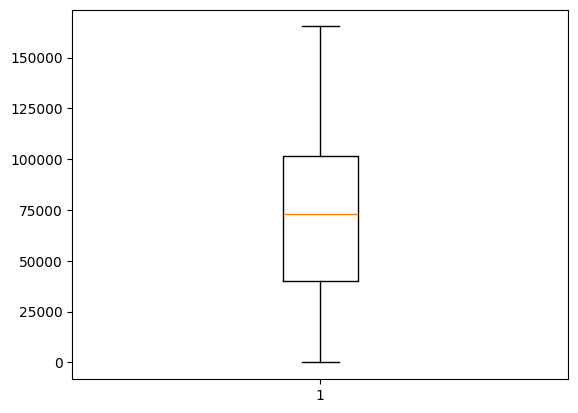

In [3]:
plt.boxplot(df["R&D Spend"])

{'whiskers': [<matplotlib.lines.Line2D at 0x1f3f26f6850>,
 'caps': [<matplotlib.lines.Line2D at 0x1f3f26f6ad0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1f3f26f6710>],
 'medians': [<matplotlib.lines.Line2D at 0x1f3f26f6d50>],
 'fliers': [<matplotlib.lines.Line2D at 0x1f3f26f6e90>],
 'means': []}

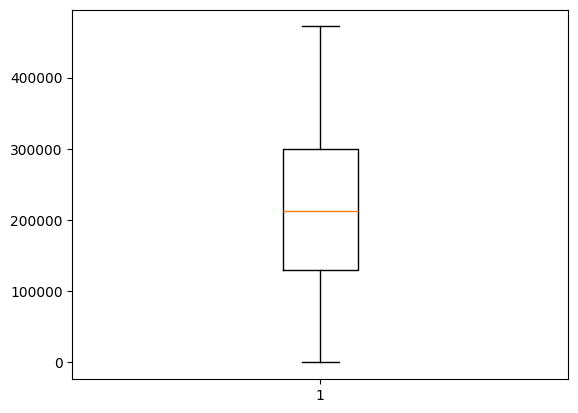

In [4]:
plt.boxplot(df['Marketing Spend'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1f3f27d1a90>,
 'caps': [<matplotlib.lines.Line2D at 0x1f3f27d1d10>,
 'boxes': [<matplotlib.lines.Line2D at 0x1f3f27d1950>],
 'medians': [<matplotlib.lines.Line2D at 0x1f3f27d1f90>],
 'fliers': [<matplotlib.lines.Line2D at 0x1f3f27d20d0>],
 'means': []}

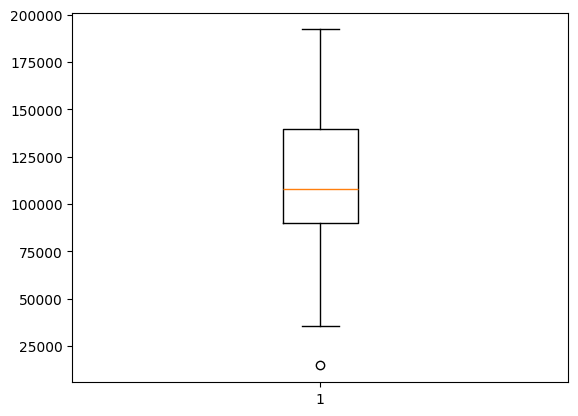

In [5]:
plt.boxplot(df["Profit"])

In [7]:
df = pd.get_dummies(df , columns=["State"],dtype = "int")

In [8]:
df.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_California,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,0,1
1,162597.70,151377.59,443898.53,191792.06,1,0,0
2,153441.51,101145.55,407934.54,191050.39,0,1,0
3,144372.41,118671.85,383199.62,182901.99,0,0,1
4,142107.34,91391.77,366168.42,166187.94,0,1,0


In [9]:
X = df.drop("Profit" , axis = 1)
y=df["Profit"]

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_train , x_test , y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state =20 )

In [13]:
x_train .shape


(40, 6)

In [14]:
from  sklearn.linear_model import LinearRegression
model = LinearRegression()


In [15]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# test 

In [16]:
test_pred = model.predict(x_test)

In [18]:
from sklearn.metrics import r2_score , root_mean_squared_error
r2_score(y_test,test_pred)

0.9438509847891488

In [19]:
root_mean_squared_error(y_test , test_pred)

10155.830400378554

In [20]:
model.intercept_

np.float64(49476.1457559958)

In [21]:
model.coef_

array([ 8.31966697e-01, -3.67454189e-02,  2.67817833e-02, -8.61802405e+01,
        1.23042055e+03, -1.14424031e+03])

In [ ]:
# deploying


In [23]:
rnd = 150000
adm = 6799
mark = 450000
state = "California"
ca,fl,ny = 0,0,0

if(state == "California" ):
    ca = 1

elif(state =="Florida"):
    fl = 1 

else:
    ny = 1

model.predict([[rnd,adm,mark,ca,fl,ny]])


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([185986.9404409])